# Sunspots

In this example we will use Sunspots data from library [statsmodels](https://www.statsmodels.org/stable/examples/notebooks/generated/statespace_arma_0.html)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from IPython.display import display, Markdown
import sys
from pathlib import Path
# shim for working with local copy
if str(Path.cwd().parent.parent.name) == 'scaleo':
    parent_dir = str(Path.cwd().parent.parent.parent)
    if parent_dir not in sys.path:
        sys.path.append(parent_dir)

from scaleo import CWT

def pprint_peaks(cwt):
    peaks = cwt.detect_power_peaks_bounds(threshold=.4)
    display(Markdown("**Detected dominant periods (years):** "))
    for p in peaks:
        peak = round(float(p[0]))
        print(f"period {peak} years: \t{", ".join([str(x.astype(int)) for x in p[1]])}" )

print(sm.datasets.sunspots.NOTE)

::

    Number of Observations - 309 (Annual 1700 - 2008)
    Number of Variables - 1
    Variable name definitions::

        SUNACTIVITY - Number of sunspots for each year

    The data file contains a 'YEAR' variable that is not returned by load.



In [2]:
dta = sm.datasets.sunspots.load_pandas().data
dta.index = pd.Index(pd.date_range("1700", end="2009", freq="YE-DEC"))
dta["YEAR"] = dta["YEAR"].astype(int)

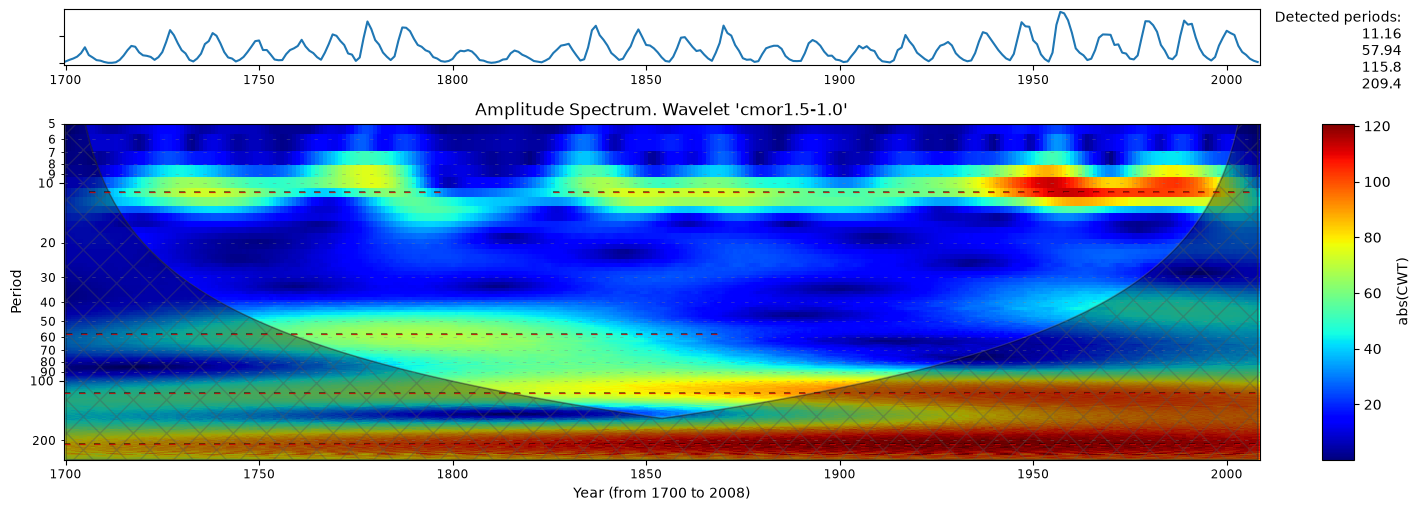

**Detected dominant periods (years):** 

period 11 years: 	[1706 1799], [1826 2007]
period 58 years: 	[1700 1869]
period 116 years: 	
period 209 years: 	


In [3]:
signal = dta['SUNACTIVITY']
time = dta['YEAR']
xlabel = r"Year (from " + dta.index.min().strftime('%Y') + r" to " + dta.index.max().strftime('%Y') +")"
cwt = CWT(signal, 1, time, 'cmor1.5-1.0', xlabel=xlabel)
_ = cwt.cwt(periods=np.linspace(5,250,200))
cwt.complex_plot(cmap='jet', figsize=(14,5), logscale=True, detect_peaks=True)
pprint_peaks(cwt)

According to [Wikipedia](https://en.wikipedia.org/wiki/Sunspot)

>Sunspots appear within active regions, usually in pairs of opposite magnetic polarity.[2] Their number varies according to the approximately 11-year [solar cycle](https://en.wikipedia.org/wiki/Solar_cycle).

Our first detected period is close to this theory. As can be seen, the **11-year period** is more clearly maintained from approximately 1950 to 2000. (See also [Cycle 22](https://en.wikipedia.org/wiki/Solar_cycle_22) and [Cycle 23](https://en.wikipedia.org/wiki/Solar_cycle_23)) At earlier observation dates, deviations from the 11-year period are more significant.

[Mexican Hat Wavelet](https://en.wikipedia.org/wiki/Complex_Mexican_hat_wavelet) will show more clearly the periods in which the signal changes its direction. Also note that when using this wavelet, the automatic dominant period detection function produces a single value.

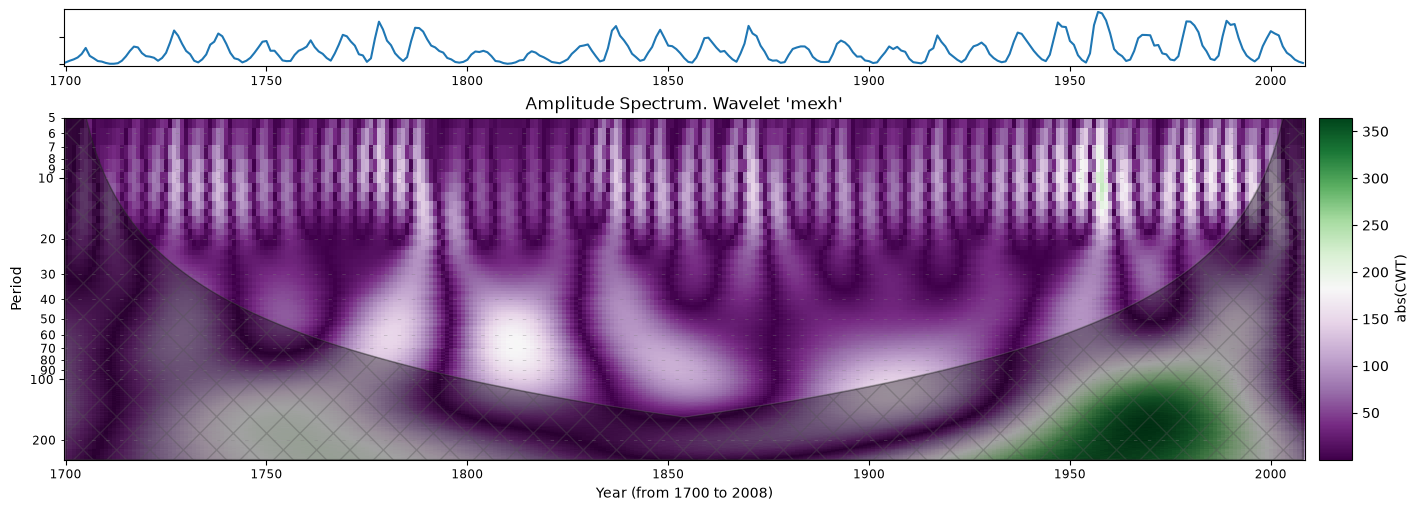

---------- 
Detected dominant periods: [11.16] years


In [4]:
cwt_mexh = CWT(signal, 1, time, 'mexh', xlabel=xlabel)
_ = cwt_mexh.cwt(periods=np.linspace(5,250,200))
cwt_mexh.complex_plot(cmap='PRGn', figsize=(14,5), logscale=True)
dominant_periods = [float(round(x,2)) for x in cwt_mexh.detect_power_peaks() if x>=2]
print("-"*10, f"\nDetected dominant periods: {dominant_periods} years")